In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('healthcare_dataset.csv')
print("Shape:", df.shape)

Shape: (55500, 15)


In [2]:
display(df.head(5))
display(df.tail(5))

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [4]:
df.describe(include='all')

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500.000000,55500,55500,55500,55500,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55500
unique,49992,NaN,2,8,6,1827,40341,39876,5,NaN,NaN,3,1856,5,3
top,DAvId muNoZ,NaN,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,2020-03-15,Lipitor,Abnormal
freq,3,NaN,27774,6969,9308,50,27,44,11249,NaN,NaN,18655,53,11140,18627
mean,NaN,51.539459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25539.316097,301.134829,NaN,NaN,NaN,NaN
std,NaN,19.602454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.454431,115.243069,NaN,NaN,NaN,NaN
min,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2008.492140,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13241.224652,202.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25538.069376,302.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37820.508436,401.000000,NaN,NaN,NaN,NaN


In [6]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [7]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dedup:", df.shape)

Duplicates: 534
Shape after dedup: (54966, 15)


In [8]:
negative_billing = df[df['Billing Amount'] < 0]
print("Rows with negative billing amount:", len(negative_billing))
negative_billing[['Name','Medical Condition','Billing Amount']].head()

Rows with negative billing amount: 106


,Name,Medical Condition,Billing Amount
132,ashLEy ERIcKSoN,Cancer,-502.507813
799,CHRisTOPHer wEiss,Asthma,-1018.245371
1018,AsHley WaRnER,Hypertension,-306.364925
1421,JAY galloWaY,Asthma,-109.097122
2103,josHUa wilLIamSon,Diabetes,-576.727907


In [9]:
df['Billing Amount'] = df['Billing Amount'].abs()

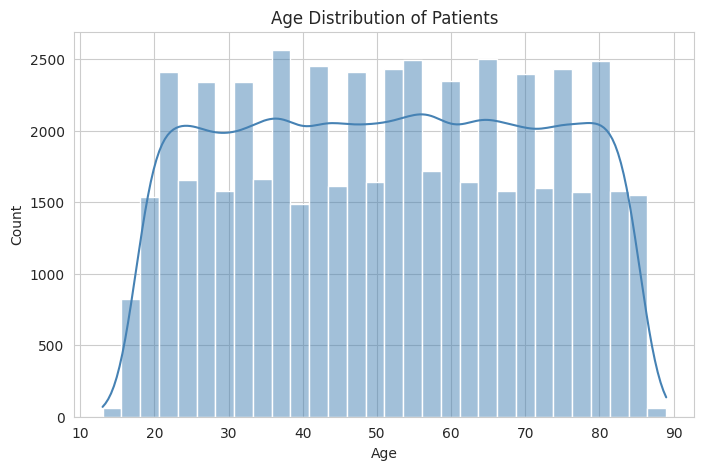

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Patients')
plt.show()

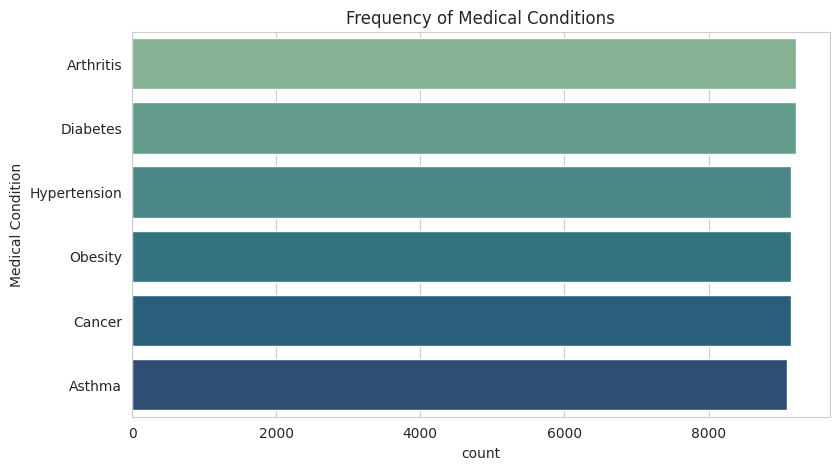

In [11]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, y='Medical Condition', order=df['Medical Condition'].value_counts().index, palette='crest')
plt.title('Frequency of Medical Conditions')
plt.show()

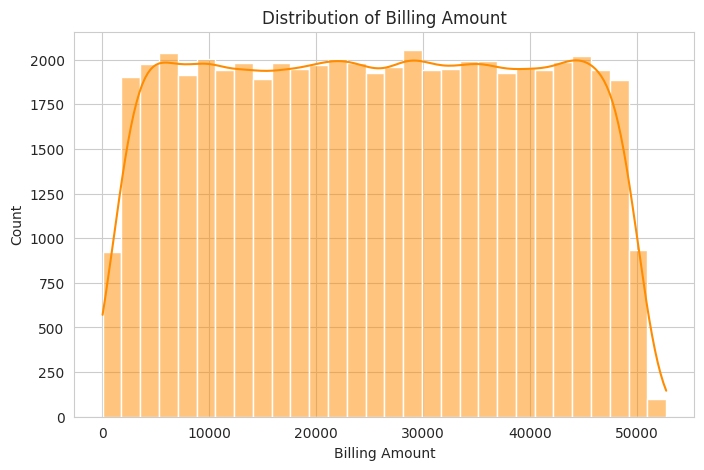

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Billing Amount'], bins=30, kde=True, color='darkorange')
plt.title('Distribution of Billing Amount')
plt.show()

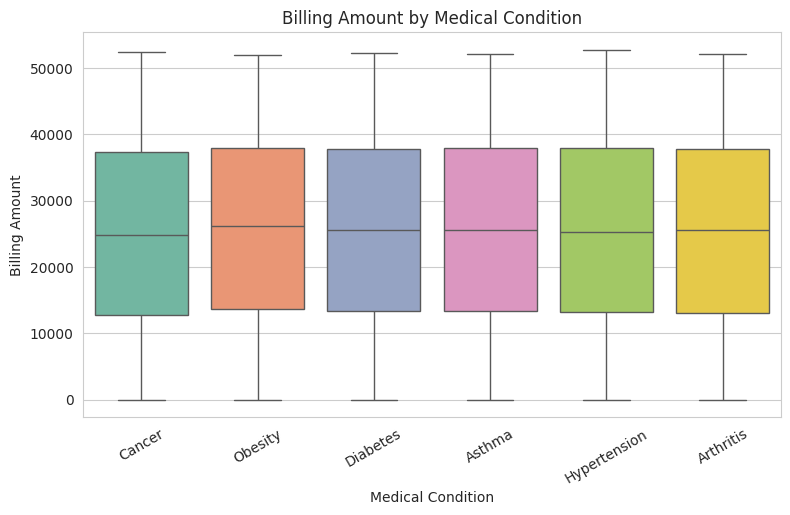

In [13]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Medical Condition', y='Billing Amount', palette='Set2')
plt.title('Billing Amount by Medical Condition')
plt.xticks(rotation=30)
plt.show()

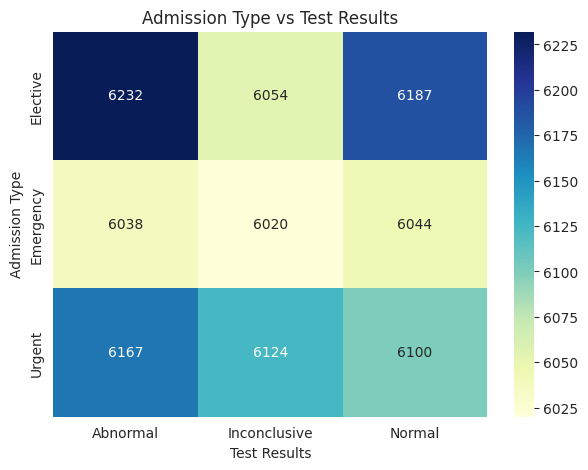

In [14]:
plt.figure(figsize=(7,5))
cross = pd.crosstab(df['Admission Type'], df['Test Results'])
sns.heatmap(cross, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Admission Type vs Test Results')
plt.show()

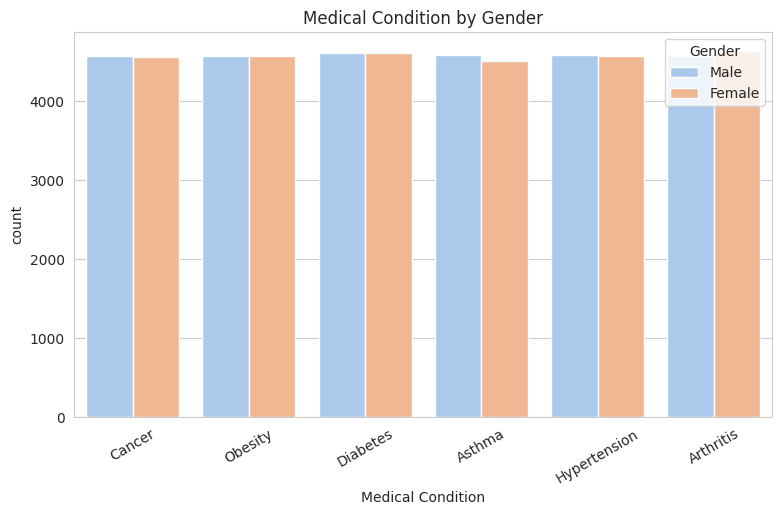

In [15]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='Medical Condition', hue='Gender', palette='pastel')
plt.title('Medical Condition by Gender')
plt.xticks(rotation=30)
plt.show()

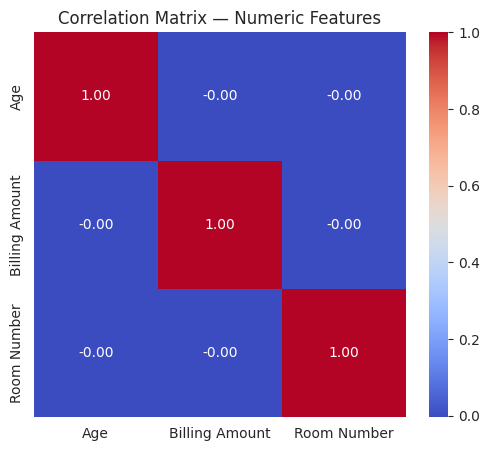

In [16]:
plt.figure(figsize=(6,5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Numeric Features')
plt.show()

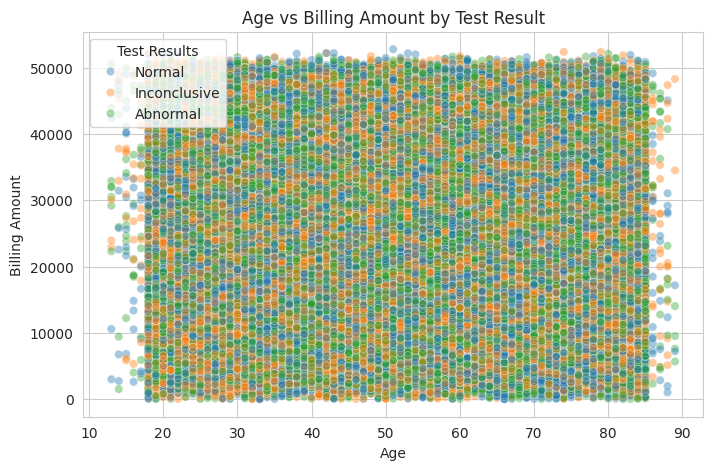

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='Billing Amount', hue='Test Results', alpha=0.4)
plt.title('Age vs Billing Amount by Test Result')
plt.show()

In [18]:
Q1 = df['Billing Amount'].quantile(0.25)
Q3 = df['Billing Amount'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['Billing Amount'] < lower) | (df['Billing Amount'] > upper)]
print("Billing Amount outliers:", len(outliers))

Billing Amount outliers: 0
